In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sequence.kernel.timeline import Timeline
from sequence.components.photon import Photon
from sequence.topology.optical_nodes import PolarizationAnalyzerNode
from sequence.topology.optical_nodes import SpdcSourceNode
from sequence.components.fiber_quantum_channel import fiberQuantumChannel, FiberSpec, FiberSection
from sequence.constants import SPEED_OF_LIGHT
from helpers import (
    sliding_windows_coincidences,
    reconstruct_rho_from_paulis,
    get_bell_state,
    fidelity,
    counts_to_probs,
    correlator_from_probs,
    plot_density_matrix_bars
)
frequency = 1e6      # Hz
mean_photon_num = 0.01  # Mean photon number
bell_state = "psi-"     # Bell state

# These will be overwritten per run
d1 = 1   # L arm distance (m)
d2 = 1   # R arm distance (m)

segment_len_m = 5_000 # 5km

attenuation1 = 0.0002   # dB/m for channel 1
attenuation2 = 0.0002   # dB/m for channel 2

# Default fiber specs WITH classical coexist (i.e. with Raman background)
fiber_spec1_with_noise = FiberSpec(
    temperature_C=20,
    classical_coexist_enabled=True,
    classical_wavelength_nm=1310.0,
    quantum_bandwidth_Hz=100e9,
    classical_power_mW=0.02
)

fiber_spec2_with_noise = FiberSpec(
    temperature_C=20,
    classical_coexist_enabled=True,
    classical_wavelength_nm=1310.0,
    quantum_bandwidth_Hz=100e9,
    classical_power_mW=0.02
)

# Fiber specs WITHOUT background noise (Raman off)
fiber_spec1_no_noise = FiberSpec(
    temperature_C=20
)

fiber_spec2_no_noise = FiberSpec(
    temperature_C=20
)

fiber_spec1 = fiber_spec1_with_noise
fiber_spec2 = fiber_spec2_with_noise

def analyze_windowed_coincidences(tags_A, tags_B, emmission_time=1, config=None):
    max_time_ps = emmission_time * 1e12
    time_integration_s = config.get("time_integration_ms", 1000) / 1000
    int_time_ps = time_integration_s * 1e12
    earliest_time = min(tags_A[0], tags_B[0]) if tags_A and tags_B else 0
    latest_time = earliest_time + max_time_ps

    coinc_list, CAR_list = [], []

    t = earliest_time
    while t < latest_time:
        win_A = [ts for ts in tags_A if t <= ts < t + int_time_ps]
        win_B = [ts for ts in tags_B if t <= ts < t + int_time_ps]
        result = sliding_windows_coincidences(config, np.array(win_A), np.array(win_B))
        coinc_list.append(result["coincidences_rate"])
        CAR_list.append(result["CAR"])
        t += int_time_ps

    coinc_array = np.array(coinc_list)
    CAR_array = np.array(CAR_list)

    if np.all(np.isinf(CAR_array)):
        CAR_mean, CAR_std = np.inf, 0.0
    else:
        finite = CAR_array[np.isfinite(CAR_array)]
        if len(finite) == 0:
            CAR_mean, CAR_std = np.nan, np.nan
        else:
            CAR_mean, CAR_std = finite.mean(), finite.std()

    return coinc_array.mean(), coinc_array.std(), CAR_mean, CAR_std


def measure_basis_pair(basisA, BasisB, emmission_time=1, config=None):
    global d1, d2, fiber_spec1, fiber_spec2
    end_time = (emmission_time * 1e12 + round(max(d1, d2) / SPEED_OF_LIGHT))
    tl = Timeline(stop_time=end_time)
    num_pulses = int(frequency * emmission_time)

    source = SpdcSourceNode("source", tl, config={
        "wavelengths": [1557.36, 1558.17],
        "bandwidth": 2,
        "frequency": frequency,
        "mean_photon_num": mean_photon_num,
        "bell_state": bell_state,
    })

    analyzer_A = PolarizationAnalyzerNode(
        "analyzer_A", tl,
        config={"mode": "hwp_qwp",
                "detector_efficiency": 0.85,
                "dark_count": 500,
                "mismeasure_prob": 0.005}
    )
    analyzer_B = PolarizationAnalyzerNode(
        "analyzer_B", tl,
        config={"mode": "hwp_qwp",
                "detector_efficiency": 0.85,
                "dark_count": 500,
                "mismeasure_prob": 0.005}
    )

    analyzer_A.set_basis(basisA)
    analyzer_B.set_basis(BasisB)

    spec_B = fiber_spec2
    n_segments = int(d2 / segment_len_m)
    
    sections_B = [
        FiberSection(length_m=segment_len_m, spec=spec_B)
        for _ in range(n_segments)
    ]


    qc_A = fiberQuantumChannel("qc_A", tl, attenuation=attenuation1, distance=d1, spec=fiber_spec1)
    qc_B = fiberQuantumChannel("qc_B", tl, attenuation=attenuation2, distance=d2, sections=sections_B)

    qc_A.set_ends(source, analyzer_A.name)
    qc_B.set_ends(source, analyzer_B.name)

    tl.init()
    source.spdc.emit(num_pulses=num_pulses)
    tl.run()

    counts_A = analyzer_A.get_photon_times()
    counts_B = analyzer_B.get_photon_times()

    config = {
        "coincidence_window_width": 2000,  # in ps
        "range_ns": 50,
        "time_bin":0.1, # in ns
        "time_integration_ms": emmission_time/10 * 1000,  # convert to ms
        "peak0": (qc_A.base_group_delay_s-qc_B.base_group_delay_s) * 1e12
    }

    hh_mean, _, _, _ = analyze_windowed_coincidences(counts_A[0], counts_B[0], emmission_time, config)
    vv_mean, _, _, _ = analyze_windowed_coincidences(counts_A[1], counts_B[1], emmission_time, config)
    hv_mean, _, _, _ = analyze_windowed_coincidences(counts_A[0], counts_B[1], emmission_time, config)
    vh_mean, _, _, _ = analyze_windowed_coincidences(counts_A[1], counts_B[0], emmission_time, config)
    probs = counts_to_probs(hh_mean, hv_mean, vh_mean, vv_mean)

    return probs, (hh_mean, hv_mean, vh_mean, vv_mean)


def run_tomography(emmission_time=1.0):
    bases = ["Z", "X", "Y"]
    probs_by_pair = {}
    T2 = {}

    for A in bases:
        for B in bases:
            P, raw = measure_basis_pair(A, B, emmission_time)
            probs_by_pair[(A, B)] = P
            T2[(A, B)] = correlator_from_probs(P)

    Tmap = {(i, j): T2[(i, j)] for i in "XYZ" for j in "XYZ"}
    rho = reconstruct_rho_from_paulis(Tmap)
    return rho, probs_by_pair, Tmap

def run_for_distance_LR(
    d_L_km,
    d_R_km,
    emmission_time=1.0,
    with_background_noise=True,
    do_plot=True
):
    """
    d_L_km: distance of arm L in km (ideal memory modeled as short/noiseless fiber).
    d_R_km: distance of arm R in km (real fiber with or without Raman).
    with_background_noise: True -> classical coexist enabled (Raman on),
                           False -> no classical channel (Raman off).
    """
    global d1, d2, fiber_spec1, fiber_spec2

    # L: ~0 to approximate perfect memory,
    d1 = d_L_km * 1000.0   # m
    d2 = d_R_km * 1000.0   # m

    if with_background_noise:
        fiber_spec1 = fiber_spec1_with_noise
        fiber_spec2 = fiber_spec2_with_noise
    else:
        fiber_spec1 = fiber_spec1_no_noise
        fiber_spec2 = fiber_spec2_no_noise

    rho, probs, T = run_tomography(emmission_time=emmission_time)

    if do_plot:
        for label in ["phi+", "phi-", "psi+", "psi-"]:
            F = fidelity(rho, get_bell_state(label))
            print(f"Fidelity({label}): {F:.3f}")
        plot_density_matrix_bars(rho, part="both", title_prefix=f"L={d_L_km}km, R={d_R_km}km, noise={with_background_noise},")

    return rho, probs, T


=== R = 10 km, WITH background noise ===
Fidelity(phi+): 0.026
Fidelity(phi-): 0.027
Fidelity(psi+): 0.023
Fidelity(psi-): 0.924


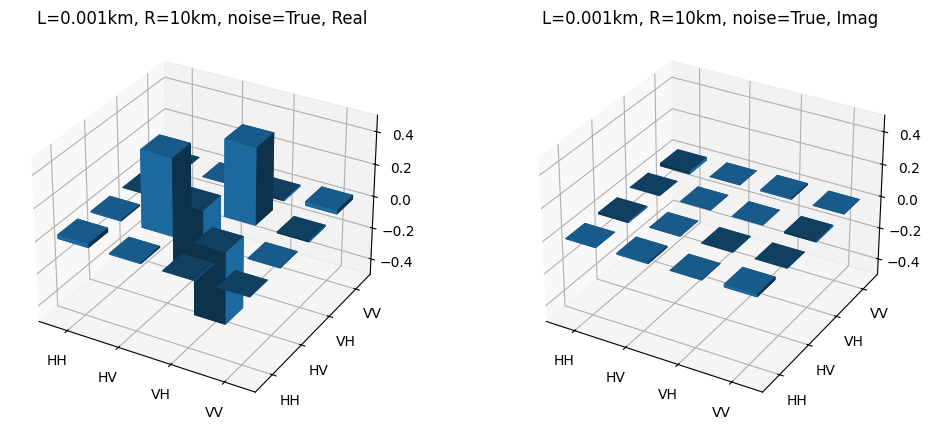


=== R = 10 km, WITHOUT background noise ===
Fidelity(phi+): 0.021
Fidelity(phi-): 0.020
Fidelity(psi+): 0.009
Fidelity(psi-): 0.951


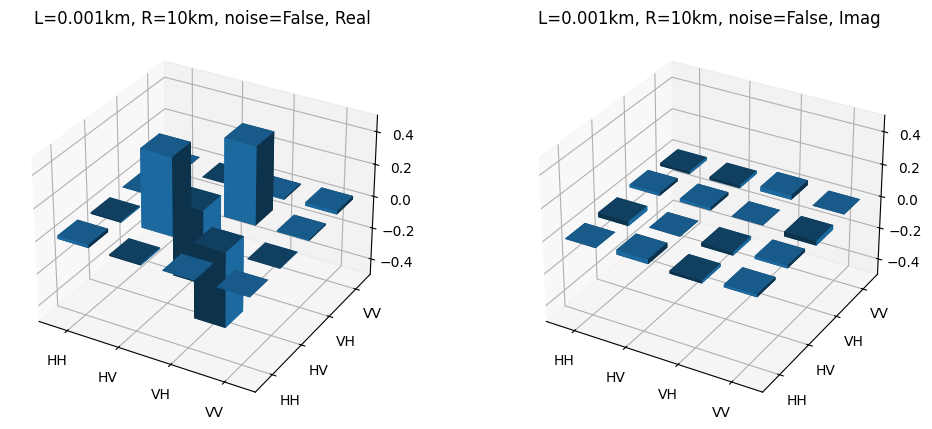


=== R = 20 km, WITH background noise ===
Fidelity(phi+): 0.031
Fidelity(phi-): 0.040
Fidelity(psi+): 0.038
Fidelity(psi-): 0.891


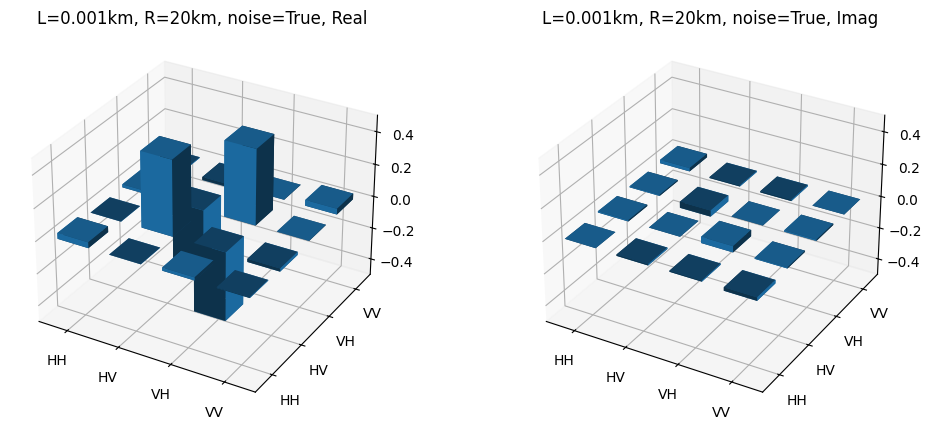


=== R = 20 km, WITHOUT background noise ===
Fidelity(phi+): 0.031
Fidelity(phi-): 0.033
Fidelity(psi+): 0.005
Fidelity(psi-): 0.931


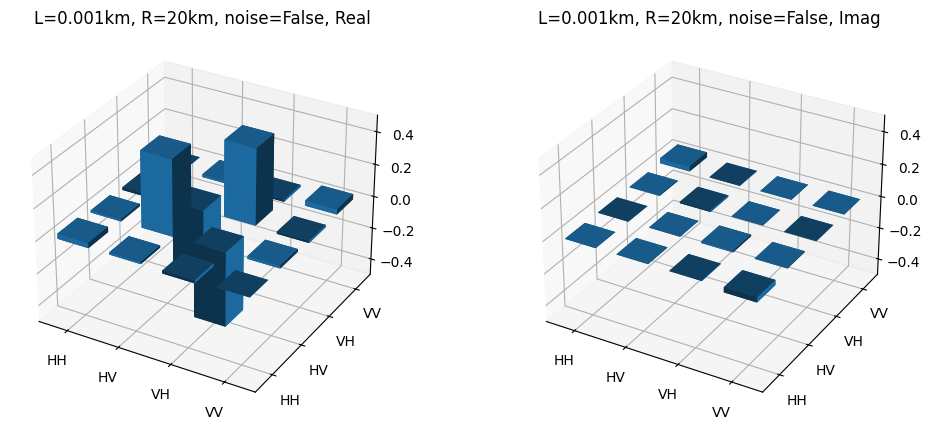


=== R = 30 km, WITH background noise ===
Fidelity(phi+): 0.042
Fidelity(phi-): 0.058
Fidelity(psi+): 0.045
Fidelity(psi-): 0.856


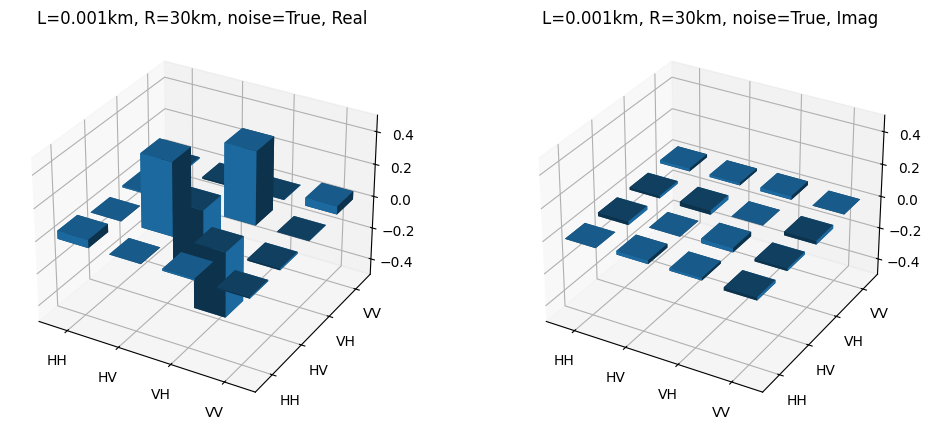


=== R = 30 km, WITHOUT background noise ===
Fidelity(phi+): 0.017
Fidelity(phi-): 0.016
Fidelity(psi+): 0.006
Fidelity(psi-): 0.961


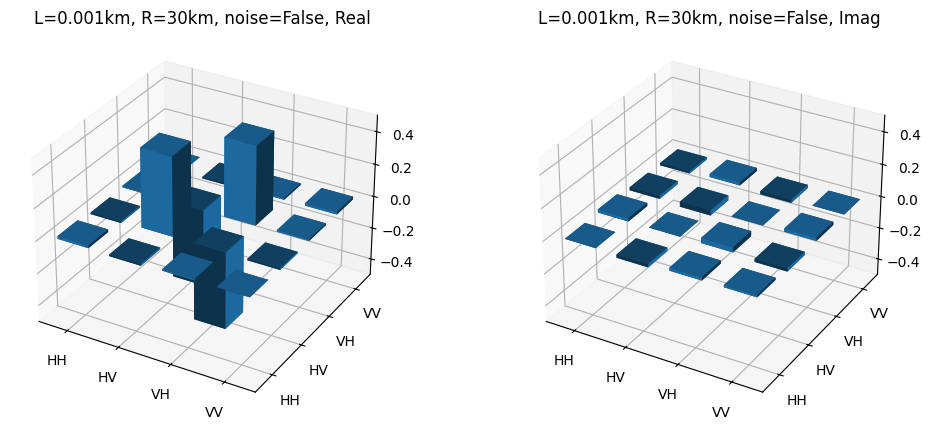


=== R = 40 km, WITH background noise ===
Fidelity(phi+): 0.111
Fidelity(phi-): 0.071
Fidelity(psi+): 0.104
Fidelity(psi-): 0.714


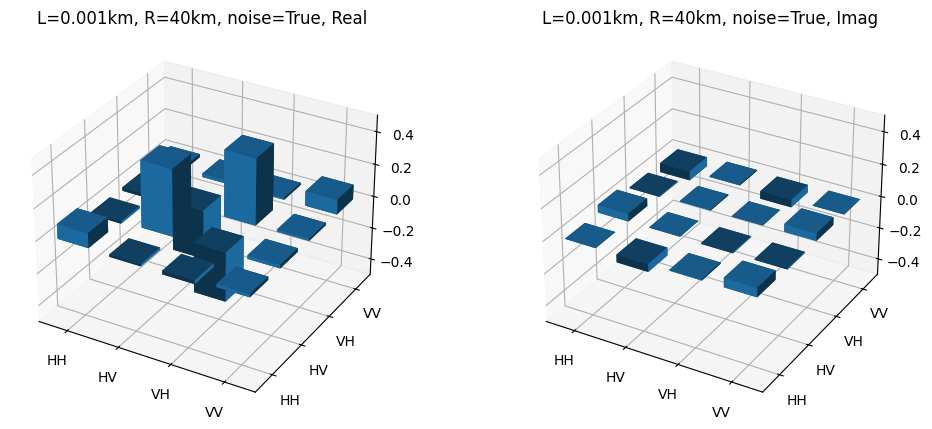


=== R = 40 km, WITHOUT background noise ===
Fidelity(phi+): 0.021
Fidelity(phi-): 0.004
Fidelity(psi+): 0.019
Fidelity(psi-): 0.956


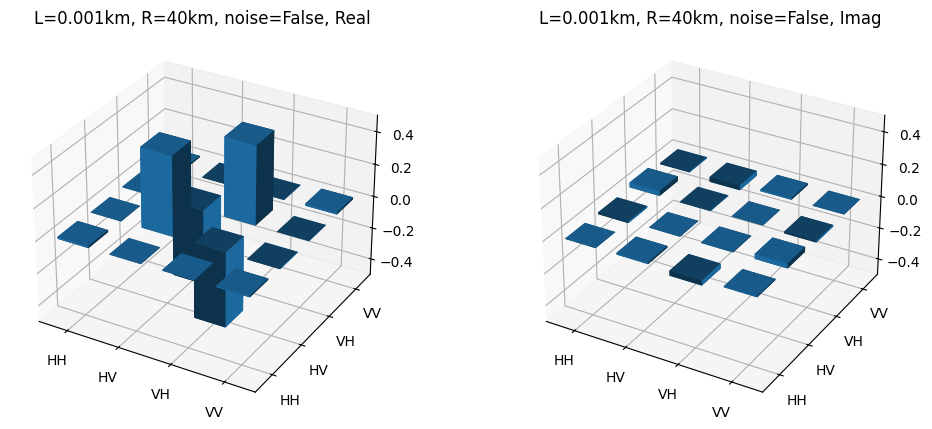


=== R = 50 km, WITH background noise ===
Fidelity(phi+): 0.200
Fidelity(phi-): 0.150
Fidelity(psi+): 0.189
Fidelity(psi-): 0.461


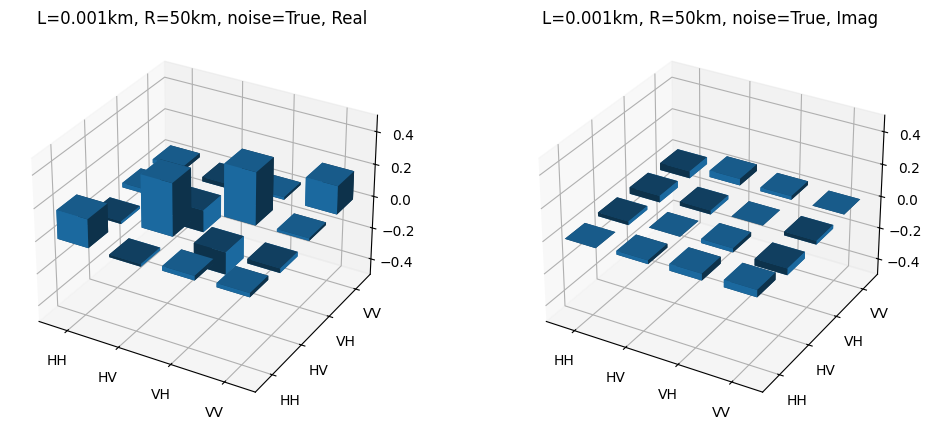


=== R = 50 km, WITHOUT background noise ===
Fidelity(phi+): 0.005
Fidelity(phi-): 0.013
Fidelity(psi+): 0.018
Fidelity(psi-): 0.964


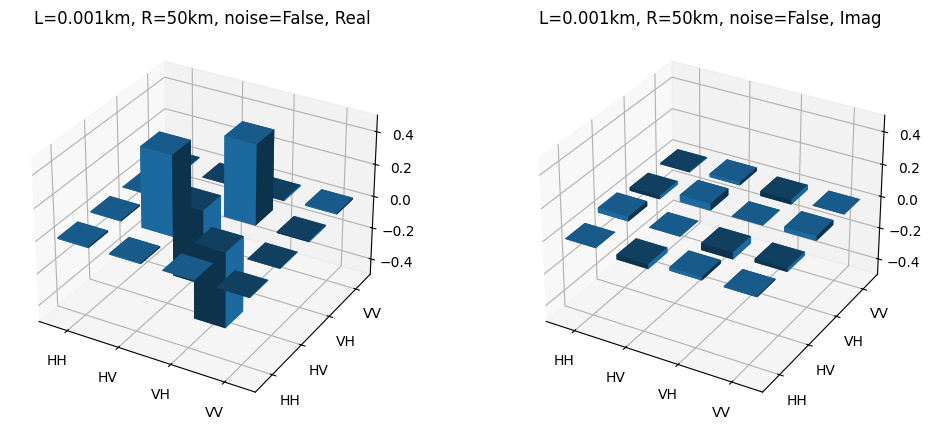

In [3]:
# Distances for R in km (10, 20, 50), L ~ 0 km
distances_R = [10, 20, 30, 40, 50]
d_L_km = 0.001  # ~1 m, effectively perfect compared to R

results = {}
for dR in distances_R:
    print(f"\n=== R = {dR} km, WITH background noise ===")
    rho_noise, probs_noise, T_noise = run_for_distance_LR(
        d_L_km=d_L_km,
        d_R_km=dR,
        emmission_time=0.1,#in seconds
        with_background_noise=True,
        do_plot=True
    )

    print(f"\n=== R = {dR} km, WITHOUT background noise ===")
    rho_no_noise, probs_no_noise, T_no_noise = run_for_distance_LR(
        d_L_km=d_L_km,
        d_R_km=dR,
        emmission_time=0.1,#in seconds
        with_background_noise=False,
        do_plot=True
    )

    results[(dR, "with_noise")] = rho_noise
    results[(dR, "no_noise")] = rho_no_noise

In [4]:
results

{(10,
  'with_noise'): array([[ 0.02646941+0.00000000e+00j,  0.00939071-1.00437367e-02j,
         -0.00332363-1.63253672e-03j, -0.00050365-1.93274375e-02j],
        [ 0.00939071+1.00437367e-02j,  0.47353059-2.70969256e-17j,
         -0.45088069+2.39045077e-03j,  0.00332363+1.63253672e-03j],
        [-0.00332363+1.63253672e-03j, -0.45088069-2.39045077e-03j,
          0.47353059+0.00000000e+00j, -0.00939071+1.00437367e-02j],
        [-0.00050365+1.93274375e-02j,  0.00332363-1.63253672e-03j,
         -0.00939071-1.00437367e-02j,  0.02646941+8.46778925e-19j]]),
 (10,
  'no_noise'): array([[ 0.02025523+0.j        , -0.00800945-0.0290205j ,
          0.00164486+0.01790783j,  0.00060962-0.01748076j],
        [-0.00800945+0.0290205j ,  0.47974477+0.j        ,
         -0.47117359+0.01986725j, -0.00164486-0.01790783j],
        [ 0.00164486-0.01790783j, -0.47117359-0.01986725j,
          0.47974477+0.j        ,  0.00800945+0.0290205j ],
        [ 0.00060962+0.01748076j, -0.00164486+0.01790783j,
